# Red Neuronal con PyTorch — Aprobación de Crédito Australiano

**Dataset:** Statlog Australian Credit Approval — UCI Machine Learning Repository

## Variable objetivo (Y)
- **0** = Crédito Rechazado
- **1** = Crédito Aprobado

## Variables de entrada (X)
| Variable | Descripción |
|---|---|
| A1 | Perfil demográfico del solicitante |
| A2 | Edad del solicitante |
| A3 | Nivel de deuda / compromiso financiero |
| A4 | Situación personal o de vivienda |
| A5 | Tipo de cliente / historial administrativo |
| A6 | Perfil laboral o educativo |
| A7 | Antigüedad laboral / estabilidad en empleo |
| A8 | Estado de riesgo previo |
| A9 | Historial crediticio previo |
| A10 | Intensidad de deuda / carga financiera actual |
| A11 | Indicador adicional de riesgo |
| A12 | Condición administrativa/legal del solicitante |
| A13 | Capacidad de pago estimada |
| A14 | Ingreso o monto financiero reportado |

In [63]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, classification_report)



In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Carga del Dataset

Cargamos el archivo `australian.dat` desde Google Drive usando pandas.
El dataset tiene 690 solicitudes de crédito bancario con 14 variables financieras cada una.
El objetivo es predecir si una solicitud será aprobada (1) o rechazada (0).

In [65]:
# Carga del dataset desde Google Drive
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Intelegencia Artificial/Dataset/australian.dat', sep=r'\s+', header=None)

X = data.iloc[:, :-1].values.astype(np.float32)  # features
y = data.iloc[:, -1].values.astype(np.float32)   # etiquetas

m = len(y)

print(f'Dimensiones X : {X.shape}')
print(f'Dimensiones y : {y.shape}')
print(f'Clases únicas : {np.unique(y, return_counts=True)}')

Dimensiones X : (690, 14)
Dimensiones y : (690,)
Clases únicas : (array([0., 1.], dtype=float32), array([383, 307]))


In [66]:
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [67]:
data.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


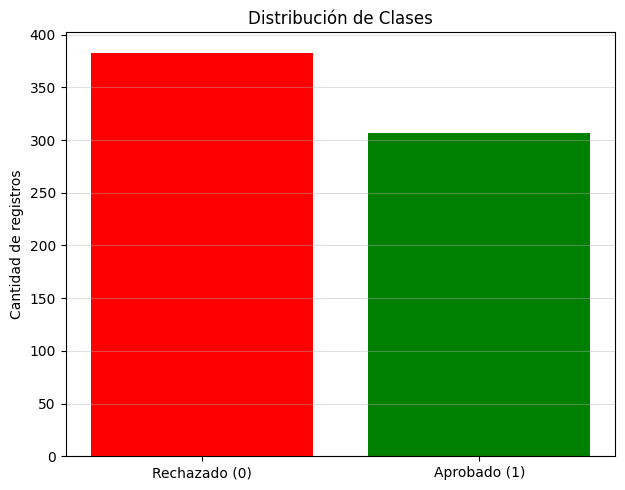

In [68]:
conteo_clases = pd.Series(y).value_counts().sort_index()
plt.figure(figsize=(12, 5))
# Barras
plt.subplot(1, 2, 1)
plt.bar(['Rechazado (0)', 'Aprobado (1)'], conteo_clases.values, color=['red', 'green'])
plt.title('Distribución de Clases')
plt.ylabel('Cantidad de registros')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 2. División y Normalización

**División 80/20**
Separamos los datos en dos conjuntos: 80% para entrenar el modelo y 20% para validar
qué tan bien aprendió con datos que nunca vio. La mezcla es aleatoria con semilla fija
para que los resultados sean reproducibles.

**Normalización Z-score**
Las 14 variables tienen escalas muy diferentes — por ejemplo A2 es edad en años
y A14 es un monto financiero en miles. Sin normalizar, las variables con valores
grandes dominarían el entrenamiento y el modelo aprendería mal.

La normalización convierte cada variable para que tenga media ≈ 0 y desviación
estándar ≈ 1 usando la fórmula: `x_norm = (x - mu) / sigma`

Importante: mu y sigma se calculan SOLO con los datos de entrenamiento y luego
se aplican a validación. Si usáramos todos los datos para calcularlos estaríamos
filtrando información del futuro al modelo — eso se llama data leakage.

In [69]:
# División 80/20
np.random.seed(42)
indices   = np.random.permutation(m)
split     = int(0.8 * m)

idx_train = indices[:split]
idx_val   = indices[split:]

X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]

print(f'Entrenamiento : {len(y_train):,} ejemplos ({len(y_train)/m*100:.1f}%)')
print(f'Validación    : {len(y_val):,} ejemplos ({len(y_val)/m*100:.1f}%)')
print(f'\nDistribución en entrenamiento:')
print(f'  Rechazado (0): {(y_train==0).sum():,}')
print(f'  Aprobado  (1): {(y_train==1).sum():,}')

Entrenamiento : 552 ejemplos (80.0%)
Validación    : 138 ejemplos (20.0%)

Distribución en entrenamiento:
  Rechazado (0): 311
  Aprobado  (1): 241


In [70]:
# Normalización con featureNormalize
def featureNormalize(X):
    X_norm = X.copy()
    mu     = np.mean(X_norm, axis=0)
    sigma  = np.std(X_norm, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X_norm - mu) / sigma
    return X_norm, mu, sigma

# Normalizar SOLO con entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicar los mismos mu y sigma a validación
X_val_norm = (X_val - mu) / sigma

print('Media entrenamiento (debe ser ≈ 0):')
print(np.mean(X_train_norm, axis=0).round(3))
print()
print('Desviación estándar (debe ser ≈ 1):')
print(np.std(X_train_norm, axis=0).round(3))

Media entrenamiento (debe ser ≈ 0):
[ 0.  0. -0.  0.  0. -0.  0.  0. -0. -0. -0. -0.  0.  0.]

Desviación estándar (debe ser ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [71]:
# Convertir a tensores de PyTorch
X_t = torch.from_numpy(X_train_norm.astype(np.float32)).float()
Y_t = torch.from_numpy(y_train.astype(np.float32)).float().view(-1, 1)

X_val_t = torch.from_numpy(X_val_norm.astype(np.float32)).float()
Y_val_t = torch.from_numpy(y_val.astype(np.float32)).float().view(-1, 1)

print(f'X_t     : {X_t.shape}')
print(f'Y_t     : {Y_t.shape}')
print(f'X_val_t : {X_val_t.shape}')
print(f'Y_val_t : {Y_val_t.shape}')

X_t     : torch.Size([552, 14])
Y_t     : torch.Size([552, 1])
X_val_t : torch.Size([138, 14])
Y_val_t : torch.Size([138, 1])


## 3. Arquitectura de la Red Neuronal

```
Entrada (14) → FC(64) → ReLU → Dropout(0.3)
             → FC(32) → ReLU → Dropout(0.3)
             → FC(16) → ReLU
             → FC(1)  → Sigmoid
```

La red tiene 3 capas ocultas que aprenden patrones cada vez más complejos
de las variables financieras.

- **ReLU** en las capas ocultas: permite aprender relaciones no lineales
  entre las variables. Si usáramos solo capas lineales el modelo no podría
  capturar combinaciones complejas como "deuda alta + empleo inestable = riesgo".
- **Dropout(0.3)**: durante el entrenamiento apaga aleatoriamente el 30% de
  las neuronas en cada paso. Esto evita que el modelo memorice los datos de
  entrenamiento y falle con datos nuevos — ese problema se llama overfitting.
- **Sigmoid** en la salida: convierte el resultado a un valor entre 0 y 1
  que interpretamos como probabilidad de que el crédito sea aprobado.

In [72]:
class RedNeuronal(nn.Module):
    def __init__(self, D_in, H1, H2, D_out):
        super(RedNeuronal, self).__init__()
        self.fc1 = nn.Linear(D_in, H1)
        self.fc2 = nn.Linear(H1, H2)
        self.fc3 = nn.Linear(H2, D_out)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x
D_in  = X_t.shape[1]  # 14 features
H1    = 32
H2    = 16
D_out = 1

modelo = RedNeuronal(D_in, H1, H2, D_out)
print(modelo)

RedNeuronal(
  (fc1): Linear(in_features=14, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## 4. Función de Pérdida y Optimizador

**BCELoss (Binary Cross-Entropy)**
Mide qué tan equivocadas son las probabilidades que predice el modelo.
Si el crédito es aprobado (y=1) pero el modelo da probabilidad baja,
la pérdida es alta. El entrenamiento busca minimizar ese número.

**Adam**
Es el optimizador que actualiza los pesos del modelo. Es más robusto que
SGD porque adapta automáticamente la velocidad de aprendizaje para cada
parámetro según cómo se ha comportado en los pasos anteriores.

**weight_decay=1e-4 (Regularización L2)**
Agrega una penalización a los pesos muy grandes. Esto obliga al modelo
a ser más simple y generalizar mejor con datos nuevos.

In [73]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=1e-3, weight_decay=1e-4)

## 5. Entrenamiento

Entrenamos por 500 épocas usando el ciclo estándar de PyTorch en cada una:
1. **forward**: pasar los datos por la red y obtener predicciones
2. **loss**: calcular qué tan equivocado está el modelo
3. **zero_grad**: limpiar los gradientes del paso anterior
4. **backward**: calcular cómo cambiar cada peso para reducir el error
5. **step**: aplicar los cambios a los pesos

En cada época también evaluamos la pérdida en validación para monitorear
si el modelo está aprendiendo bien o sobreajustando.

In [74]:
epochs   = 500
log_each = 100
train_loss_hist = []
val_loss_hist   = []

for e in range(1, epochs + 1):

    # --- Entrenamiento ---
    modelo.train()
    y_pred = modelo(X_t)
    loss   = criterion(y_pred, Y_t)
    train_loss_hist.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # --- Validación ---
    modelo.eval()
    with torch.no_grad():
        loss_val = criterion(modelo(X_val_t), Y_val_t)
    val_loss_hist.append(loss_val.item())

    if not e % log_each:
        print(f'Época {e}/{epochs} | Loss Train: {loss.item():.5f} | Loss Val: {loss_val.item():.5f}')

Época 100/500 | Loss Train: 0.38252 | Loss Val: 0.34535
Época 200/500 | Loss Train: 0.32082 | Loss Val: 0.29796
Época 300/500 | Loss Train: 0.30638 | Loss Val: 0.29505
Época 400/500 | Loss Train: 0.27969 | Loss Val: 0.29468
Época 500/500 | Loss Train: 0.27597 | Loss Val: 0.29918


## 6. Curvas de Convergencia

Graficamos cómo evoluciona la pérdida durante el entrenamiento.

- Si train_loss y val_loss bajan juntas el modelo está aprendiendo bien.
- Si train_loss sigue bajando pero val_loss sube hay overfitting —
  el modelo está memorizando en lugar de aprender.

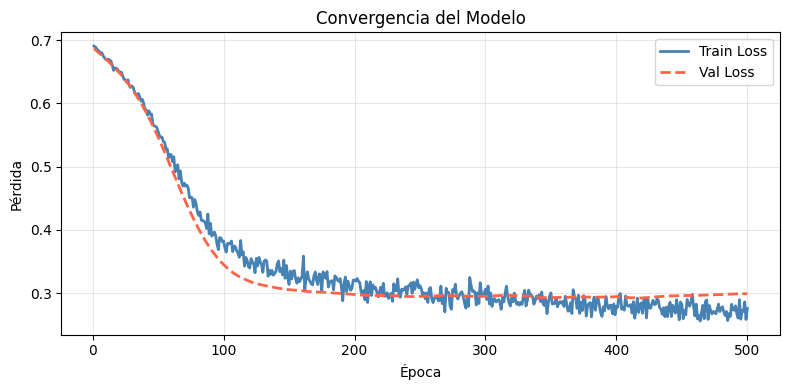

In [75]:
epocas = range(1, len(train_loss_hist) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epocas, train_loss_hist, label='Train Loss', lw=2, color='steelblue')
plt.plot(epocas, val_loss_hist,   label='Val Loss',   lw=2, color='tomato', linestyle='--')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Convergencia del Modelo')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Métricas de Evaluación

La accuracy sola no es suficiente para este problema. En crédito bancario
los errores tienen costos muy diferentes:

- **Falso Positivo**: aprobamos a alguien que no puede pagar → el banco pierde dinero
- **Falso Negativo**: rechazamos a alguien que sí podía pagar → perdemos un cliente

Por eso usamos métricas más completas:

| Métrica | Qué mide |
|---|---|
| **Accuracy** | Porcentaje total de predicciones correctas |
| **Precision** | De los que predijimos como aprobados, ¿cuántos realmente podían pagar? |
| **Recall** | De todos los que podían pagar, ¿cuántos detectamos correctamente? |
| **F1-Score** | Balance entre Precision y Recall |
| **AUC-ROC** | Qué tan bien separa el modelo aprobados de rechazados en general |

In [76]:
modelo.eval()
with torch.no_grad():
    # probabilidades y predicciones de entrenamiento
    probs = modelo(X_t).numpy().ravel()
    preds = (probs >= 0.5).astype(int)  # umbral 0.5: mayor → aprobado

# métricas de entrenamiento
print('Entrenamiento:')
print(f'Accuracy  : {accuracy_score(y_train, preds):.4f}')   # % total acertados
print(f'Precision : {precision_score(y_train, preds):.4f}')  # % aprobados que realmente podían pagar
print(f'Recall    : {recall_score(y_train, preds):.4f}')     # % buenos clientes detectados
print(f'F1-Score  : {f1_score(y_train, preds):.4f}')         # balance precision y recall
print(f'AUC-ROC   : {roc_auc_score(y_train, probs):.4f}')   # qué tan bien separa las clases

with torch.no_grad():
    # probabilidades y predicciones de validación
    probs_val = modelo(X_val_t).numpy().ravel()
    preds_val = (probs_val >= 0.5).astype(int)

print('\nValidación:')
print(f'Accuracy  : {accuracy_score(y_val, preds_val):.4f}')
print(f'Precision : {precision_score(y_val, preds_val):.4f}')
print(f'Recall    : {recall_score(y_val, preds_val):.4f}')
print(f'F1-Score  : {f1_score(y_val, preds_val):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_val, probs_val):.4f}')

Entrenamiento:
Accuracy  : 0.9076
Precision : 0.8770
Recall    : 0.9170
F1-Score  : 0.8966
AUC-ROC   : 0.9645

Validación:
Accuracy  : 0.8696
Precision : 0.8429
Recall    : 0.8939
F1-Score  : 0.8676
AUC-ROC   : 0.9487


### ¿Cuándo priorizar Precision y cuándo Recall?

Si el banco quiere **minimizar pérdidas** (no aprobar créditos malos) → prioriza Precision alta.
Si el banco quiere **no perder clientes** (no rechazar buenos solicitantes) → prioriza Recall alto.
El F1-Score nos da el punto de equilibrio entre ambos.

## 8. Matriz de Confusión

Muestra en detalle los 4 tipos de resultados posibles del modelo:

| | Predicho: Rechazado | Predicho: Aprobado |
|---|---|---|
| **Real: Rechazado** | TN — rechazamos correctamente | FP — aprobamos por error |
| **Real: Aprobado** | FN — rechazamos por error | TP — aprobamos correctamente |

Los FP son los más costosos para el banco porque representan créditos
aprobados a personas que no pueden pagar.

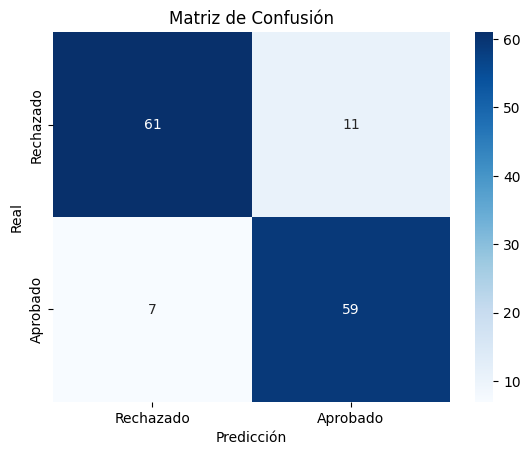

TN: 61  — Rechazados correctamente
FP: 11  — Aprobados incorrectamente
FN: 7  — Rechazados incorrectamente
TP: 59  — Aprobados correctamente


In [77]:
import seaborn as sns
cm = confusion_matrix(y_val, preds_val)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rechazado', 'Aprobado'],
            yticklabels=['Rechazado', 'Aprobado'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN: {tn}  — Rechazados correctamente')
print(f'FP: {fp}  — Aprobados incorrectamente')
print(f'FN: {fn}  — Rechazados incorrectamente')
print(f'TP: {tp}  — Aprobados correctamente')

## 9. Curva ROC y AUC

La curva ROC muestra el balance entre detectar aprobados correctamente
y cometer errores aprobando rechazados.

- **AUC = 1.0** → el modelo separa perfectamente las dos clases
- **AUC = 0.5** → el modelo no sirve, predice al azar
- **AUC > 0.85** → buen modelo para este tipo de problema

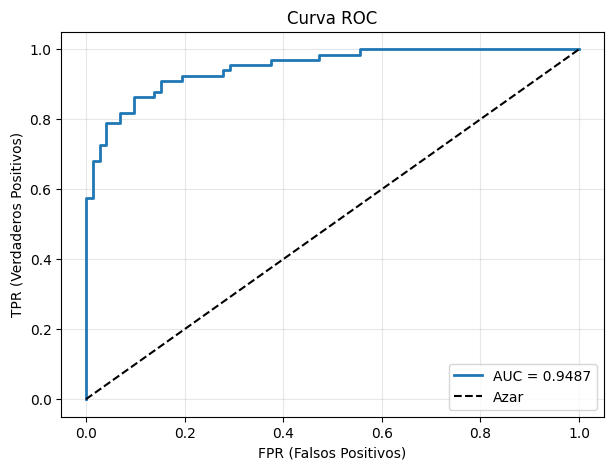

AUC-ROC: 0.9487


In [78]:
fpr, tpr, _ = roc_curve(y_val, probs_val)
auc = roc_auc_score(y_val, probs_val)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Azar')
plt.xlabel('FPR (Falsos Positivos)')
plt.ylabel('TPR (Verdaderos Positivos)')
plt.title('Curva ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'AUC-ROC: {auc:.4f}')

## 10. Reporte de Clasificación

Resumen completo de Precision, Recall y F1-Score separado por clase.
Nos permite ver si el modelo rinde bien tanto para aprobados como para rechazados,
o si tiene sesgo hacia una de las clases.

In [79]:
from sklearn.metrics import classification_report

print(classification_report(
    y_val, preds_val,
    target_names=['Rechazado (0)', 'Aprobado (1)']
))

               precision    recall  f1-score   support

Rechazado (0)       0.90      0.85      0.87        72
 Aprobado (1)       0.84      0.89      0.87        66

     accuracy                           0.87       138
    macro avg       0.87      0.87      0.87       138
 weighted avg       0.87      0.87      0.87       138



## 11. Predicciones Individuales

Mostramos las primeras 20 predicciones del conjunto de validación
con la probabilidad asignada por el modelo. Esto nos permite ver
caso por caso si el modelo está tomando buenas decisiones.

In [82]:
for i in range(20):
    real = int(y_val[i])
    pred = int(preds_val[i])
    prob = float(probs_val[i])
    ok   = 'bien' if real == pred else 'mal'
    er   = 'Aprobado' if real == 1 else 'Rechazado'
    ep   = 'Aprobado' if pred == 1 else 'Rechazado'
    print(f'{i+1:>3} | Real: {er:>9} | Pred: {ep:>9} | Prob: {prob:.4f} | {ok}')

  1 | Real:  Aprobado | Pred:  Aprobado | Prob: 0.9761 | bien
  2 | Real:  Aprobado | Pred: Rechazado | Prob: 0.4615 | mal
  3 | Real:  Aprobado | Pred:  Aprobado | Prob: 0.9886 | bien
  4 | Real: Rechazado | Pred: Rechazado | Prob: 0.2453 | bien
  5 | Real:  Aprobado | Pred:  Aprobado | Prob: 0.9716 | bien
  6 | Real: Rechazado | Pred: Rechazado | Prob: 0.0075 | bien
  7 | Real: Rechazado | Pred: Rechazado | Prob: 0.0046 | bien
  8 | Real: Rechazado | Pred:  Aprobado | Prob: 0.5314 | mal
  9 | Real:  Aprobado | Pred:  Aprobado | Prob: 0.5151 | bien
 10 | Real: Rechazado | Pred: Rechazado | Prob: 0.0418 | bien
 11 | Real: Rechazado | Pred:  Aprobado | Prob: 0.6378 | mal
 12 | Real:  Aprobado | Pred: Rechazado | Prob: 0.0425 | mal
 13 | Real: Rechazado | Pred: Rechazado | Prob: 0.1761 | bien
 14 | Real:  Aprobado | Pred:  Aprobado | Prob: 0.9667 | bien
 15 | Real: Rechazado | Pred: Rechazado | Prob: 0.0101 | bien
 16 | Real: Rechazado | Pred: Rechazado | Prob: 0.2115 | bien
 17 | Real: 

## Resumen Final

| Componente | Detalle |
|---|---|
| **Arquitectura** | 14 → 64 → 32 → 16 → 1 |
| **Activación oculta** | ReLU — aprende patrones no lineales |
| **Activación salida** | Sigmoid — produce probabilidad entre 0 y 1 |
| **Pérdida** | BCELoss — adecuada para clasificación binaria |
| **Optimizador** | Adam con lr=1e-3 y weight_decay=1e-4 |
| **Regularización** | Dropout 30% en capas 1 y 2 |
| **Épocas** | 500 |